In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [17]:
data = pd.read_csv(r"C:\Users\Dell\OneDrive\Documents\python\project\IPL2025Batters.csv")
data 

,Player Name,Team,Runs,Matches,Inn,No,HS,AVG,BF,SR,100s,50s,4s,6s
0,Sai Sudharsan,GT,759,15,15,1,108*,54.21,486,156.17,1,6,88,21
1,Surya Kumar Yadav,MI,717,16,16,5,73*,65.18,427,167.91,0,5,69,38
2,Virat Kohli,RCB,657,15,15,3,73*,54.75,454,144.71,0,8,66,19
3,Shubman Gill,GT,650,15,15,2,93*,50.00,417,155.87,0,6,62,24
4,Mitchell Marsh,LSG,627,13,13,0,117,48.23,383,163.70,1,6,56,37
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
151,Khaleel Ahmed,CSK,1,14,2,2,1*,-,2,50.00,0,0,0,0
152,Mohit Sharma,DC,1,8,2,1,1*,1.00,3,33.33,0,0,0,0
153,Donovan Ferreira,DC,1,1,1,0,1,1.00,3,33.33,0,0,0,0
154,Digvesh Singh,LSG,1,13,2,1,1,1.00,3,33.33,0,0,0,0


In [18]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Player Name  156 non-null    object 
 1   Team         156 non-null    object 
 2   Runs         156 non-null    int64  
 3   Matches      156 non-null    int64  
 4   Inn          156 non-null    int64  
 5   No           156 non-null    int64  
 6   HS           156 non-null    object 
 7   AVG          156 non-null    object 
 8   BF           156 non-null    int64  
 9   SR           156 non-null    float64
 10  100s         156 non-null    int64  
 11  50s          156 non-null    int64  
 12  4s           156 non-null    int64  
 13  6s           156 non-null    int64  
dtypes: float64(1), int64(9), object(4)
memory usage: 17.2+ KB


In [19]:
print(data.isnull().sum())

Player Name    0
Team           0
Runs           0
Matches        0
Inn            0
No             0
HS             0
AVG            0
BF             0
SR             0
100s           0
50s            0
4s             0
6s             0
dtype: int64


In [20]:
data = data.dropna()

In [21]:
data['AVG'] = pd.to_numeric(data['AVG'], errors='coerce')

X = data[['Matches','AVG','SR','4s','6s']]
y = data['Runs']

In [22]:
X = X.fillna(X.mean())

In [23]:
print(data['AVG'].dtype)

float64


In [24]:
print(data['AVG'].isnull().sum())

15


In [25]:
print(data[['Matches', 'AVG', 'SR', '4s', '6s']].dtypes)

Matches      int64
AVG        float64
SR         float64
4s           int64
6s           int64
dtype: object


In [26]:
X = data[['Matches','AVG','SR','4s','6s']]
X = X.fillna(X.mean())

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [28]:
print(X_train.isnull().sum())

Matches    0
AVG        0
SR         0
4s         0
6s         0
dtype: int64


In [29]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[ 41.87679463 139.94337306  89.01529521 103.8472315   21.96923043
 277.09815775  43.59321956  -2.88054387  41.77105745  19.82553519]


In [30]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 15.204256328157895
MSE: 450.70480285621943
R2 Score: 0.9823953368824762


In [31]:
new_player = [[50, 40.5, 135.2, 120, 45]]

predicted_runs = model.predict(new_player)

print("Predicted Runs:", predicted_runs[0])

Predicted Runs: 1141.2171351052332


C:\Users\Dell\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [33]:
import pandas as pd

results = pd.DataFrame({
    'Actual Runs': y_test,
    'Predicted Runs': y_pred
})

print(results.head(10))

     Actual Runs  Predicted Runs
96            40       41.876795
69           121      139.943373
82            74       89.015295
76            97      103.847232
114           13       21.969230
29           301      277.098158
94            47       43.593220
132            6       -2.880544
93            48       41.771057
139            4       19.825535


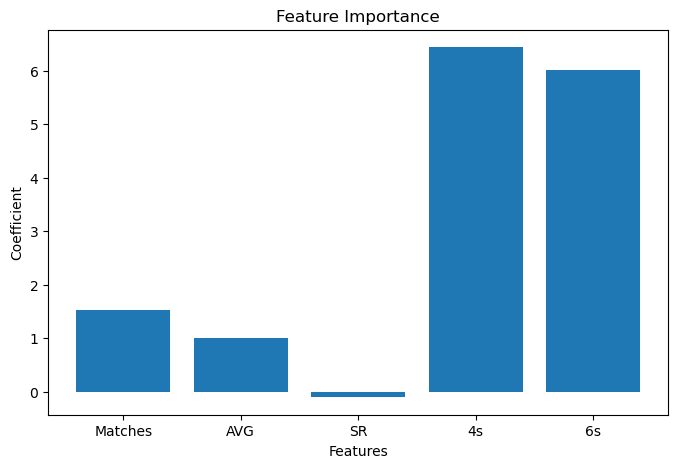

In [35]:
features = X.columns

plt.figure(figsize=(8,5))
plt.bar(features, model.coef_)
plt.xlabel("Features")
plt.ylabel("Coefficient")
plt.title("Feature Importance")
plt.show()

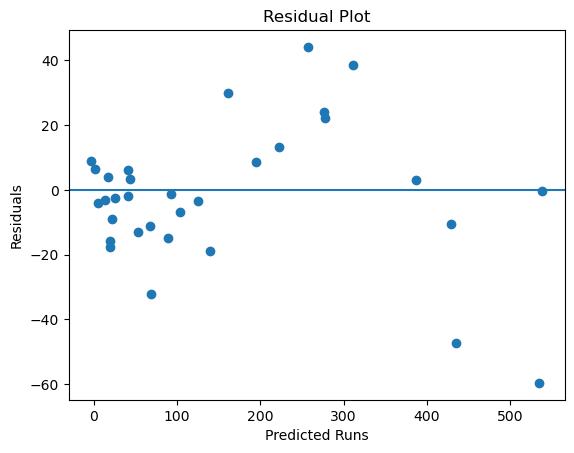

In [34]:
residuals = y_test - y_pred

plt.scatter(y_pred, residuals)
plt.axhline(y=0)
plt.xlabel("Predicted Runs")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

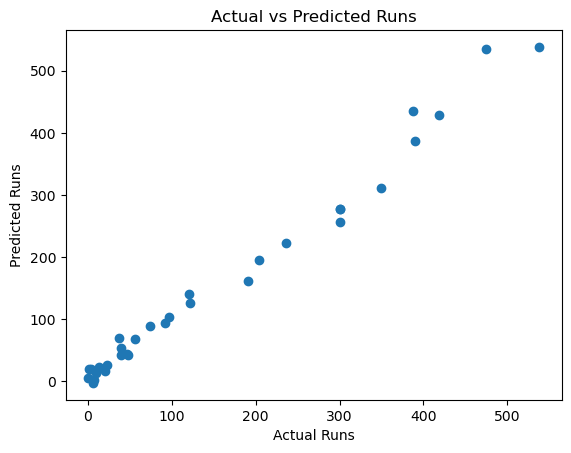

In [37]:


plt.scatter(y_test, y_pred)
plt.xlabel("Actual Runs")
plt.ylabel("Predicted Runs")
plt.title("Actual vs Predicted Runs")
plt.show()